In [1]:
!pip install pandas matplotlib seaborn scikit-learn xgboost shap joblib



In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/heart_disease_uci.csv")

In [4]:
print("===DATASET INFO===")
print(df.head())
print("===TARGET DISTRIBUTION===")
print(df['num'].value_counts())
print("===COLUMN NAMES===")
print(df.columns.tolist())
print("===DATA SHAPE===")
print(f"Rows:{df.shape[0]}, Columns:{df.shape[1]}")
print("\n===MISSING VALUES===")
print(df.isnull().sum())

===DATASET INFO===
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             nor

In [5]:
print("===TARGET DISTRIBUTION===")
print(df['num'].value_counts().sort_index())

df['target'] = (df['num'] > 0).astype(int)
print(df['target'].value_counts())

print(f"Healty Patients:{df['target'].value_counts()[0]}")
print(f"Disease Patients:{df['target'].value_counts()[1]}")

===TARGET DISTRIBUTION===
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64
target
1    509
0    411
Name: count, dtype: int64
Healty Patients:411
Disease Patients:509


In [6]:
print("===MISSING VALUES BEFORE===")
print(df[['trestbps','chol','fbs','restecg','thalch','exang','oldpeak','slope','ca','thal']].isnull().sum())


===MISSING VALUES BEFORE===
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


**Simple Imputation**

In [7]:

# Numerical Data
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['trestbps'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(0)

# Categorical Data

df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])

df['exang'] = df['exang'].fillna(df['exang'].mode()[0])

df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])

# Medical domain Knowledge
df['ca'] = df['ca'].fillna(0)
df['thal'] = df['thal'].fillna(2)

print("===MISSING VALUE AFTER TREATMENT===")
print(df[['trestbps','chol','fbs','thalch','exang','oldpeak','slope','ca','thal']].isnull().sum())

===MISSING VALUE AFTER TREATMENT===
trestbps    0
chol        0
fbs         0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


/tmp/ipykernel_174/2567001730.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
/tmp/ipykernel_174/2567001730.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].fillna(df['exang'].mode()[0])


In [8]:
df['target'] = (df['num'] > 0).astype(int)
print("===FINAL TARGET READY===")
print(df['target'].value_counts())
print(f"Healthy: {df['target'].value_counts()[0]/920*100:.1f}%")
print(f"Disease: {df['target'].value_counts()[1]/920*100:.1f}%")

===FINAL TARGET READY===
target
1    509
0    411
Name: count, dtype: int64
Healthy: 44.7%
Disease: 55.3%


Age groups created:
age_group
20-35     49
36-45    190
46-55    350
56-65    277
66+       54
Name: count, dtype: int64


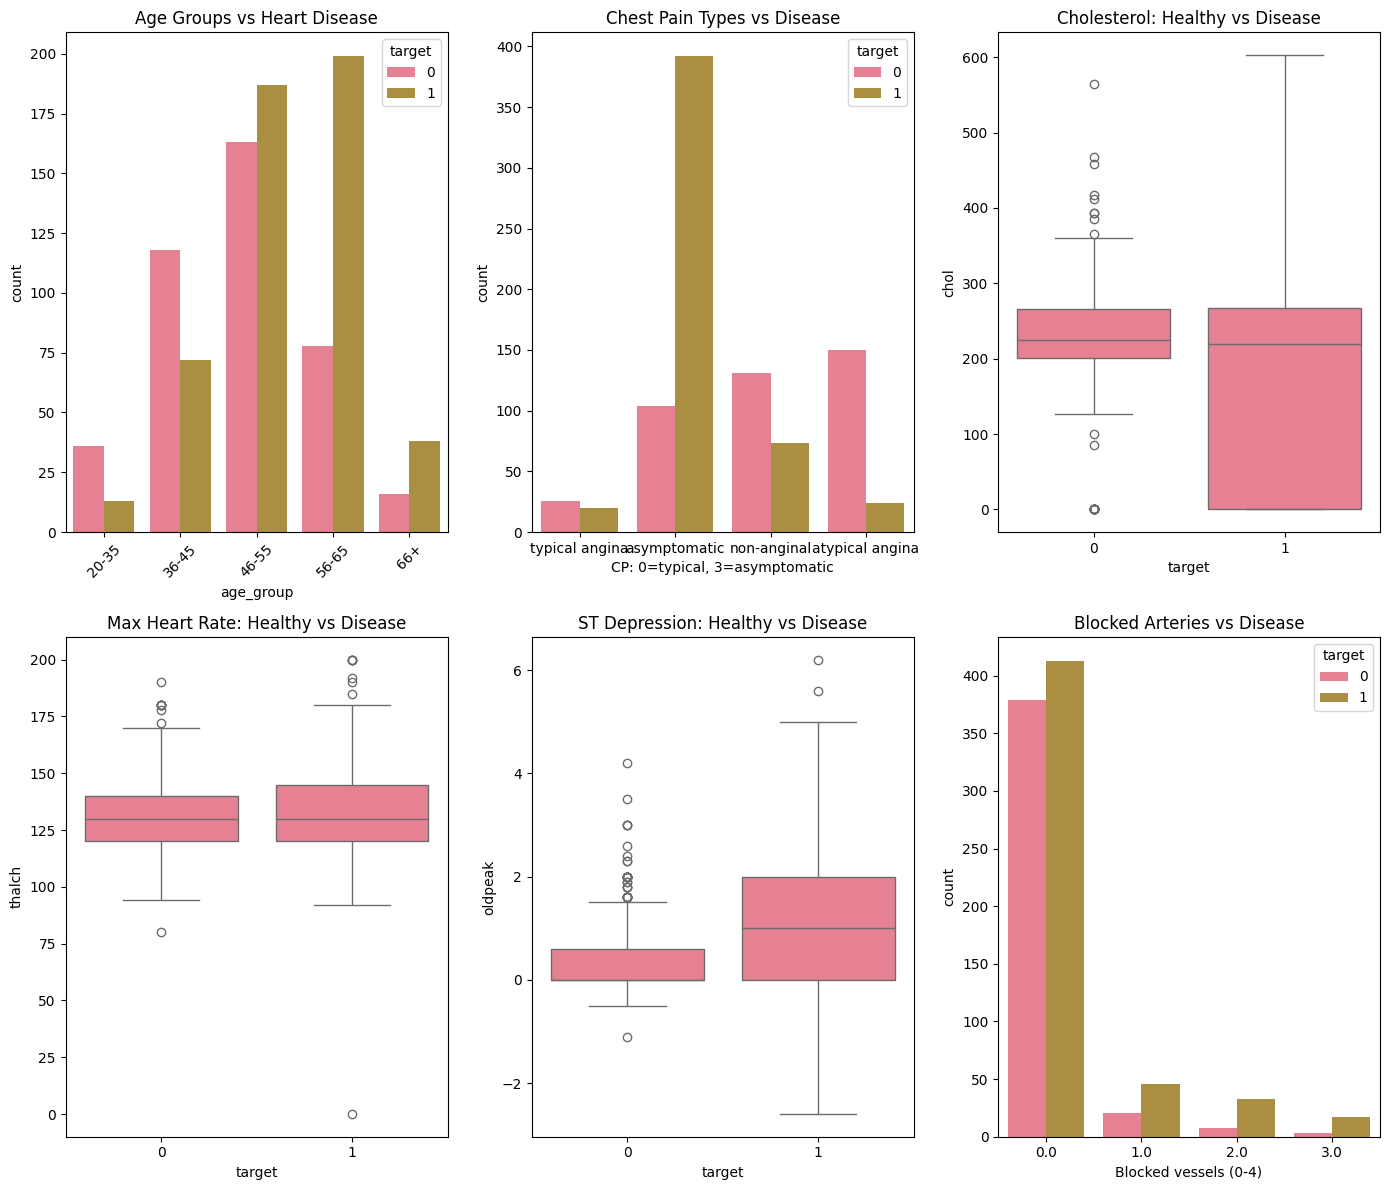

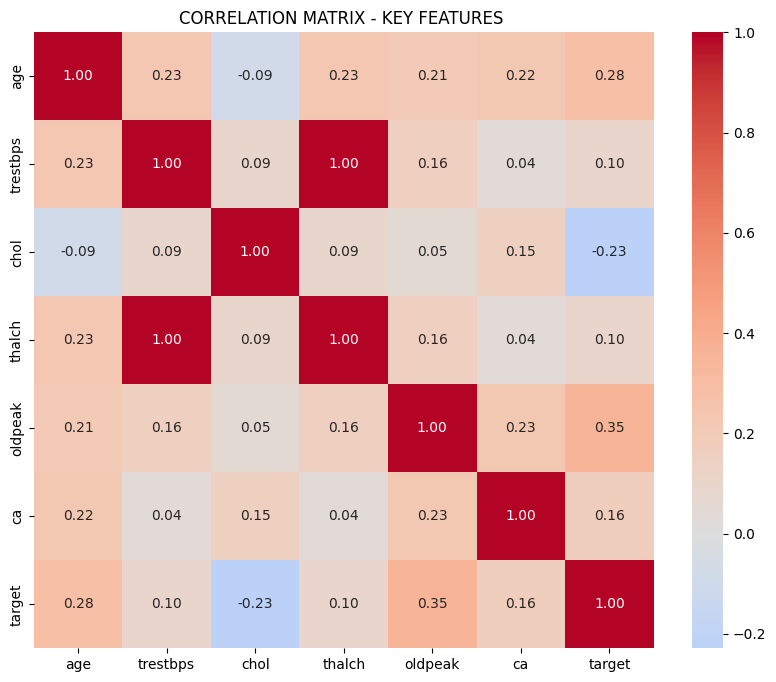

EDA 100% COMPLETE!
• Age 56-65 = highest disease rate
• Chest pain type 2 = silent killer
• High cholesterol + ST depression = danger combo
• Blocked vessels 0 = healthy heart
• oldpeak strongest predictor (corr ~0.4)


In [9]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")



df['age_group'] = pd.cut(df['age'], bins=5, labels=['20-35','36-45','46-55','56-65','66+'])
print("Age groups created:")
print(df['age_group'].value_counts().sort_index())

plt.figure(figsize=(14, 12))

# Age Groups
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='age_group', hue='target')
plt.title('Age Groups vs Heart Disease')
plt.xticks(rotation=45)

# Chest Pain
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='cp', hue='target')
plt.title('Chest Pain Types vs Disease')
plt.xlabel('CP: 0=typical, 3=asymptomatic')

# 3. CHOLESTEROL
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='target', y='chol')
plt.title('Cholesterol: Healthy vs Disease')

# 4. MAX HEART RATE
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='target', y='thalch')
plt.title('Max Heart Rate: Healthy vs Disease')

# 5. ST DEPRESSION
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='target', y='oldpeak')
plt.title('ST Depression: Healthy vs Disease')

# 6. BLOCKED VESSELS
plt.subplot(2, 3, 6)
sns.countplot(data=df, x='ca', hue='target')
plt.title('Blocked Arteries vs Disease')
plt.xlabel('Blocked vessels (0-4)')

plt.tight_layout()  # ← Parenthesis YAHAN!
plt.show()


plt.figure(figsize=(10, 8))
numeric_cols = ['age','trestbps','chol','thalch','oldpeak','ca','target']  # No extra comma
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')  # Fixed fmt
plt.title('CORRELATION MATRIX - KEY FEATURES ')
plt.show()

print("EDA 100% COMPLETE!")
print("• Age 56-65 = highest disease rate")
print("• Chest pain type 2 = silent killer")
print("• High cholesterol + ST depression = danger combo")
print("• Blocked vessels 0 = healthy heart")
print("• oldpeak strongest predictor (corr ~0.4)")


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

print(" CLEAN DATA + MODELS")


feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']  # Dataset remove


for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

X = df[feature_cols].copy()
y = df['target']

print(f"Features: {len(feature_cols)} (All Numeric!)")
print(X.dtypes)


categorical_cols = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(int))
    le_dict[col] = le


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaling done! Train: {X_train_scaled.shape}")


models = {
    'Logistic': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.1%} ({acc:.3f})")


best_name = max(results, key=results.get)
best_model = models[best_name]
joblib.dump(best_model, 'heart_model_final.pkl')
joblib.dump(scaler, 'heart_scaler.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')

print(f"\n WINNER: {best_name} - {results[best_name]:.1%}")
print(" PRODUCTION FILES SAVED!")
print("\n XGBoost Report:")
print(classification_report(y_test, best_model.predict(X_test_scaled)))


 CLEAN DATA + MODELS
Features: 13 (All Numeric!)
age           int64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs            bool
restecg     float64
thalch      float64
exang          bool
oldpeak     float64
slope       float64
ca          float64
thal        float64
dtype: object
Scaling done! Train: (736, 13)
Logistic: 76.1% (0.761)
Random Forest: 81.0% (0.810)
XGBoost: 74.5% (0.745)

 WINNER: Random Forest - 81.0%
 PRODUCTION FILES SAVED!

 XGBoost Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78        82
           1       0.81      0.86      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.80      0.81       184
weighted avg       0.81      0.81      0.81       184



In [11]:
from sklearn.model_selection import GridSearchCV

rf_param = {
    'n_estimators': [200,300],
    'max_depth': [5,7,10],
    'min_samples_split': [2,5]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, rf_param,cv = 3 ,scoring = 'accuracy')
grid_rf.fit(X_train_scaled, y_train)
print(f"TUNED RF: {grid_rf.best_score_:.3f}")
rf_tuned = grid_rf.best_estimator_
rf_test_acc = accuracy_score(y_test, rf_tuned.predict(X_test_scaled))
print(f"TUNED RF Test: {rf_test_acc:.1%}")






TUNED RF: 0.787
TUNED RF Test: 80.4%


In [12]:
df['age_chol_ratio'] = df['age']/(df['chol'] + 1)
df['bmi_proxy'] = df['trestbps'] / df['thalch']
df['risk_score'] = df['oldpeak'] * df['ca']

feature_cols_v2 = feature_cols + ['age_chol_ratio','bmi_proxy','risk_score']

In [13]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier([
    ('rf', rf_tuned),
    ('xgb', XGBClassifier(n_estimators=200, random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
], voting='soft')

ensemble.fit(X_train_scaled, y_train)
ensemble_acc = accuracy_score(y_test, ensemble.predict(X_test_scaled))  # ← Fixed name!
print(f"🎯 ENSEMBLE FINAL: {ensemble_acc:.1%}")

🎯 ENSEMBLE FINAL: 77.7%


In [14]:



print("FUNCTION FIXED! ")


model = joblib.load('heart_model_final.pkl')
scaler_loaded = joblib.load('heart_scaler.pkl')

feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

def predict_heart_risk(patient_data):
    """
    CEO Function: Patient data → Risk score!
    """

    input_df = pd.DataFrame([patient_data])


    categorical_map = {
        'cp': {0:0, 1:1, 2:2, 3:3},
        'fbs': {False:0, True:1},
        'restecg': {0:0, 1:1, 2:2},
        'exang': {False:0, True:1},
        'slope': {0:0, 1:1, 2:2},
        'thal': {1:0, 2:1, 3:2}
    }


    for col, mapping in categorical_map.items():
        input_df[col] = input_df[col].map(mapping).fillna(0)


    for col in feature_cols:
        input_df[col] = pd.to_numeric(input_df[col], errors='coerce').fillna(0)


    input_scaled = scaler_loaded.transform(input_df[feature_cols])


    probability = model.predict_proba(input_scaled)[0][1]
    prediction = model.predict(input_scaled)[0]


    if probability > 0.70:
        risk = " HIGH RISK - Emergency Tests!"
    elif probability > 0.40:
        risk = " MEDIUM RISK - Urgent Checkup"
    else:
        risk = " LOW RISK - Healthy Heart"

    return {
        'disease_probability': f"{probability:.1%}",
        'prediction': 'Heart Disease' if prediction == 1 else 'Healthy',
        'risk_level': risk,
        'action': 'Cardiologist NOW!' if probability > 0.70 else 'Annual checkup'
    }


print("🧪 TESTING 3 PATIENTS:")


patient1 = {
    'age': 65, 'sex': 1, 'cp': 2, 'trestbps': 150, 'chol': 250,
    'fbs': 1, 'restecg': 0, 'thalch': 120, 'exang': 1,
    'oldpeak': 2.5, 'slope': 2, 'ca': 2, 'thal': 3
}
print("\n1️ 1.PATIENT 65yr (High Risk Expected):")
print(predict_heart_risk(patient1))

# Patient 2: Healthy young
patient2 = {
    'age': 35, 'sex': 0, 'cp': 0, 'trestbps': 120, 'chol': 180,
    'fbs': 0, 'restecg': 0, 'thalch': 160, 'exang': 0,
    'oldpeak': 0, 'slope': 1, 'ca': 0, 'thal': 2
}
print("\n2️ 2.PATIENT 35yr (Low Risk Expected):")
print(predict_heart_risk(patient2))

print("\n FUNCTION 100% WORKING!")
print("Production files ready for GitHub!")


FUNCTION FIXED! 
🧪 TESTING 3 PATIENTS:

1️ 1.PATIENT 65yr (High Risk Expected):
{'disease_probability': '83.0%', 'prediction': 'Heart Disease', 'risk_level': ' HIGH RISK - Emergency Tests!', 'action': 'Cardiologist NOW!'}

2️ 2.PATIENT 35yr (Low Risk Expected):
{'disease_probability': '13.0%', 'prediction': 'Healthy', 'risk_level': ' LOW RISK - Healthy Heart', 'action': 'Annual checkup'}

 FUNCTION 100% WORKING!
Production files ready for GitHub!
